# 07 — SPP1-TAM prevalence by treatment condition (single-cell)

*"How many SPP1-TAMs are there in each treatment arm?"* — the question 01c **cannot** answer, and
the single-cell counterpart to what 06 does spatially.

### Why this needs its own notebook
01c §4 splits macrophages into Spp1 terciles **within each sample**, which was the correct fix for
the treatment confound (per-cell Spp1 is 4-25x higher in NoTx, so a pooled split makes
"Spp1-high" partly mean "untreated"). But that split **normalises prevalence away by
construction**: every sample gets its own top-25% cut, so ~25% of macrophages are "high" in every
arm by definition.

The two questions need opposite tools:

| question | split | notebook |
|---|---|---|
| *What defines the SPP1-TAM state?* | **within-sample** (treatment-blind) | 01c §4 |
| *How many SPP1-TAMs are there?* | **global / absolute** cut | **this one** |

### Why this is not circular
The 48-gene signature was derived from a **within-sample** DE, so it never saw treatment as a
variable — it is a treatment-blind description of the cell state. Using it now to count cells per
arm is therefore a legitimate measurement. Had the signature been built on the globally-pooled
split, this analysis would be circular (the signature would encode "untreated" and we would be
rediscovering that).

### The metric that matters most
`frac_tam_high` = the fraction of **macrophages** that are SPP1-TAM-high. Because it is a
proportion *within* the macrophage compartment, it is **not affected by dissociation capture
bias** — unlike `mac_pct_of_cells`, which is. Read `frac_tam_high` and `mean_sig` as the robust
state metrics; read the abundance metrics with the capture-bias caveat attached.

In [ ]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt

import scanpy as sc

from scipy.stats import mannwhitneyu

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80); pd.set_option("display.width", 240)

## 1. Config

In [ ]:
SC_REF  = Path("/coh_labs/yunroseli/Jona/CAR-T/data/zarr/fullDataset/"
               "annotating_references/annotation_v4.h5ad")
OUT_DIR = Path("/coh_labs/yunroseli/Jona/CAR-T/results/spp1_analysis")
FIG_DIR = OUT_DIR / "figures"
SIG_CSV = OUT_DIR / "sc_spp1_tam_signature.csv"        # written by 01c §5
OUT_DIR.mkdir(parents=True, exist_ok=True); FIG_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_COL   = "file_name"
TUMOUR_LABEL = "Cancer_cell"
MAC_LABELS   = ["M1_like_Mac", "M2_like_Mac", "Intermediate_Mac"]

# SINGLE-CELL arm names are CyTAG72 / RTCyTAG72 (the SPATIAL object spells them CyT72 / RTCyT72).
COND_META = {
    "NoTx":      {"RT": False, "cart": "none",        "cy": False},
    "CyTAG72":   {"RT": False, "cart": "nonspecific", "cy": True},
    "CyPSCA":    {"RT": False, "cart": "PSCA",        "cy": True},
    "RTCyTAG72": {"RT": True,  "cart": "nonspecific", "cy": True},
    "RTCyPSCA":  {"RT": True,  "cart": "PSCA",        "cy": True},
    # spatial aliases, harmless if absent here
    "CyT72":     {"RT": False, "cart": "nonspecific", "cy": True},
    "RTCyT72":   {"RT": True,  "cart": "nonspecific", "cy": True},
}
CONDITION_ORDER = ["NoTx", "CyTAG72", "CyPSCA", "RTCyTAG72", "RTCyPSCA"]

TAM_HIGH_Q  = 0.75     # GLOBAL cut: SPP1-TAM-high = top quartile of the signature across pooled macs
MIN_MACS    = 50       # per sample, below this the sample's fractions are unstable
STATE_METRICS = ["frac_tam_high", "mean_sig"]                       # capture-bias robust
ABUND_METRICS = ["mac_pct_of_cells", "tam_pct_of_cells"]            # capture-bias affected
METRICS = STATE_METRICS + ABUND_METRICS

assert SC_REF.exists(), f"reference not found: {SC_REF}"
print("config ready ->", OUT_DIR)

## 2. Load, score the signature, build the design

In [14]:
scref = sc.read_h5ad(SC_REF)

lvl_cols = [c for c in scref.obs.columns if c.startswith("cell_type_lvl")]
want = set(MAC_LABELS) | {TUMOUR_LABEL}
CT_COL = max(lvl_cols, key=lambda c: len(set(scref.obs[c].astype(str)) & want))
sc_ct = scref.obs[CT_COL].astype(str)
print(f"cells: {scref.n_obs:,} | genes: {scref.n_vars:,} | using {CT_COL}")

X = scref.X
head = X[:200].toarray() if sp.issparse(X) else X[:200]
if bool(np.allclose(head, np.round(head))) and float(X.max()) > 50:
    scref.layers["counts"] = scref.X.copy()
    sc.pp.normalize_total(scref, target_sum=1e4); sc.pp.log1p(scref)
    print("normalized raw counts -> CP10K + log1p")
else:
    print(".X already log-normalized")

def expr_of(gene):
    v = scref[:, gene].X
    return np.asarray(v.todense()).ravel() if sp.issparse(v) else np.asarray(v).ravel()

sig_genes = pd.read_csv(SIG_CSV)["gene"].tolist()
present = [g for g in sig_genes if g in scref.var_names]
print(f"signature: {len(present)}/{len(sig_genes)} genes present")
if len(present) < len(sig_genes):
    print("  missing:", [g for g in sig_genes if g not in scref.var_names])
assert len(present) >= 8, "too few signature genes present"
sc.tl.score_genes(scref, gene_list=present, score_name="SPP1_TAM_sig", use_raw=False, random_state=0)
scref.obs["Spp1_expr"] = expr_of("Spp1")
scref.obs["is_mac"] = sc_ct.isin(MAC_LABELS).values
scref.obs["mac_subtype"] = np.where(scref.obs["is_mac"], sc_ct.values, "not_mac")

assert SAMPLE_COL in scref.obs.columns, f"{SAMPLE_COL} not in obs"
_p = scref.obs[SAMPLE_COL].astype(str).str.extract(
    r"^(?P<cond>.*)_Tu(?P<tumor_loc>\d+)_(?P<rep>\d+)$")
assert _p["cond"].notna().all(), "some file_name values do not match <cond>_Tu<loc>_<rep>"
scref.obs["cond"]      = _p["cond"].values
scref.obs["tumor_loc"] = _p["tumor_loc"].astype(int).values
scref.obs["rep"]       = _p["rep"].astype(int).values
scref.obs["sample"]    = scref.obs[SAMPLE_COL].astype(str).values
scref.obs["mouse"]     = scref.obs["cond"] + "_rep" + scref.obs["rep"].astype(str)
scref.obs["group"]     = scref.obs["cond"] + "_Tu" + scref.obs["tumor_loc"].astype(str)

unknown = sorted(set(scref.obs["cond"]) - set(COND_META))
if unknown:
    print(f"\n!! arms not in COND_META (no cart axis for them): {unknown}")
COND_PRESENT = [c for c in CONDITION_ORDER if c in set(scref.obs["cond"])] + unknown
GROUPS = [f"{c}_Tu{t}" for c in COND_PRESENT for t in (1, 2)
          if f"{c}_Tu{t}" in set(scref.obs["group"])]

KeyboardInterrupt: 

## 3. The global SPP1-TAM cut, and the per-sample table

One absolute threshold across all pooled macrophages, so a cell's call does not depend on which
sample it came from. That is exactly what makes prevalence comparable across arms.

In [15]:
obs = scref.obs
mac_all = obs.loc[obs["is_mac"]]
SIG_CUT = float(mac_all["SPP1_TAM_sig"].quantile(TAM_HIGH_Q))
RAW_CUT = float(mac_all["Spp1_expr"].quantile(TAM_HIGH_Q))     # sensitivity comparator
obs["tam_high"] = obs["is_mac"].values & (obs["SPP1_TAM_sig"].values >= SIG_CUT)
obs["spp1_high_raw"] = obs["is_mac"].values & (obs["Spp1_expr"].values >= RAW_CUT)
print(f"macrophages: {len(mac_all):,} | SPP1-TAM-high cut = {SIG_CUT:.4f} "
      f"({int(obs['tam_high'].sum()):,} cells = {100*obs['tam_high'].sum()/len(mac_all):.1f}% of macs)")
print(f"raw-Spp1 comparator cut = {RAW_CUT:.4f}")

rows = []
for samp, d in obs.groupby("sample", observed=True):
    macs = d[d["is_mac"]]
    if len(macs) < MIN_MACS:
        print(f"skip {samp}: {len(macs)} macs (< {MIN_MACS})"); continue
    m = d.iloc[0]
    rows.append({
        "sample": samp, "cond": m["cond"], "tumor_loc": m["tumor_loc"], "rep": m["rep"],
        "mouse": m["mouse"], "group": m["group"],
        "n_cells": len(d), "n_mac": len(macs), "n_tam_high": int(macs["tam_high"].sum()),
        "frac_tam_high": float(macs["tam_high"].mean()),
        "mean_sig": float(macs["SPP1_TAM_sig"].mean()),
        "mac_pct_of_cells": 100 * len(macs) / len(d),
        "tam_pct_of_cells": 100 * int(macs["tam_high"].sum()) / len(d),
        "frac_spp1_high_raw": float(macs["spp1_high_raw"].mean()),
        "mean_spp1_raw": float(macs["Spp1_expr"].mean()),
    })
prev = pd.DataFrame(rows)
prev["cond"] = pd.Categorical(prev["cond"], COND_PRESENT, ordered=True)
prev = prev.sort_values(["cond", "tumor_loc", "rep"])
prev.to_csv(OUT_DIR / "sc_spp1tam_prevalence_per_sample.csv", index=False)

by_group = (prev.groupby("group", observed=True)
            .agg(n_samples=("sample", "count"), n_mac=("n_mac", "sum"),
                 **{m: (m, "mean") for m in METRICS},
                 **{f"{m}_sd": (m, "std") for m in METRICS},
                 frac_spp1_high_raw=("frac_spp1_high_raw", "mean"))
            .reindex(GROUPS))
by_group.to_csv(OUT_DIR / "sc_spp1tam_prevalence_by_group.csv")

by_cond = (prev.groupby("cond", observed=True)
           .agg(n_samples=("sample", "count"), n_mac=("n_mac", "sum"),
                **{m: (m, "mean") for m in METRICS},
                frac_spp1_high_raw=("frac_spp1_high_raw", "mean"))
           .reindex(COND_PRESENT))
by_cond.to_csv(OUT_DIR / "sc_spp1tam_prevalence_by_condition.csv")

print("\n=== SPP1-TAM prevalence by ARM (mean across samples) ===")
print(by_cond.round(3).to_string())
print("\n=== by arm x tumour location ===")
print(by_group[["n_samples"] + METRICS].round(3).to_string())
print("\n  frac_tam_high = % of macrophages carrying the SPP1-TAM program (capture-bias ROBUST)")
print("  mac_pct_of_cells / tam_pct_of_cells = abundance (capture-bias AFFECTED - see caveat)")

macrophages: 48,475 | SPP1-TAM-high cut = 0.3442 (12,119 cells = 25.0% of macs)
raw-Spp1 comparator cut = 1.8735

=== SPP1-TAM prevalence by ARM (mean across samples) ===
           n_samples  n_mac  frac_tam_high  mean_sig  mac_pct_of_cells  tam_pct_of_cells  frac_spp1_high_raw
cond                                                                                                        
NoTx               6   2059          0.363     0.223            26.417            10.174               0.677
CyTAG72            5  12216          0.319     0.158            55.119            17.826               0.328
CyPSCA             6   7558          0.169    -0.020            48.439             8.183               0.178
RTCyTAG72          6  14413          0.277     0.112            54.875            15.380               0.305
RTCyPSCA           6  12229          0.156    -0.011            54.897             8.679               0.160

=== by arm x tumour location ===
               n_samples  frac_t

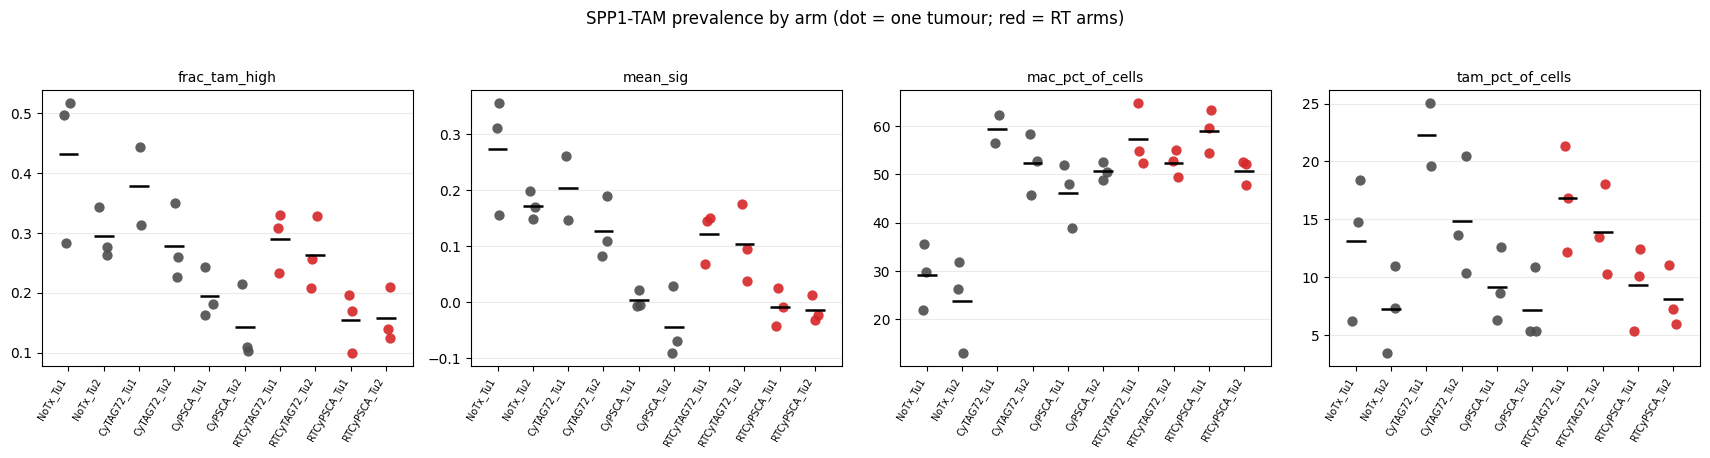

In [16]:
colors = {c: ("#d62728" if COND_META.get(c, {}).get("RT") else "#4d4d4d") for c in COND_PRESENT}
rng = np.random.default_rng(0)
xmap = {g: i for i, g in enumerate(GROUPS)}
fig, axes = plt.subplots(1, len(METRICS), figsize=(4.3 * len(METRICS), 4.4))
for ax, met in zip(np.atleast_1d(axes), METRICS):
    for g in GROUPS:
        s = prev[prev["group"] == g]
        v = s[met].dropna().values
        ax.scatter(xmap[g] + rng.uniform(-0.13, 0.13, len(v)), v, s=55,
                   color=colors.get(s["cond"].iloc[0] if len(s) else "NoTx", "k"),
                   alpha=0.9, linewidths=0, zorder=3)
        if len(v):
            ax.hlines(np.mean(v), xmap[g] - 0.28, xmap[g] + 0.28, color="k", lw=1.8, zorder=4)
    ax.set_xticks(list(xmap.values())); ax.set_xticklabels(GROUPS, rotation=60, ha="right", fontsize=7)
    ax.set_title(met, fontsize=10); ax.grid(axis="y", alpha=0.25)
fig.suptitle("SPP1-TAM prevalence by arm (dot = one tumour; red = RT arms)", y=1.03, fontsize=12)
fig.tight_layout(); fig.savefig(FIG_DIR / "sc_spp1tam_prevalence.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)

## 4. Recruitment vs state

`tam_pct_of_cells = mac_pct_of_cells x frac_tam_high`, so on a log2 scale the burden change
decomposes **additively** into a recruitment term and a state term:

`log2(burden) = log2(mac abundance) + log2(fraction high)`

Which term dominates decides the mechanism — and the follow-up experiment.

In [17]:
# tam_pct = mac_pct x frac_high holds EXACTLY per sample, so in log2 space the burden is exactly
# the sum of the two terms. We therefore log-transform PER SAMPLE and average the logs (a geometric
# mean). Averaging the raw ratios first would break additivity, because E[XY] != E[X]E[Y] whenever
# recruitment and state covary across replicates within an arm.
LOGCOLS = {"log2_recruitment": "mac_pct_of_cells",
           "log2_state":       "frac_tam_high",
           "log2_burden":      "tam_pct_of_cells"}
lg = prev[["sample", "cond", "tumor_loc", "group"]].copy()
for k, m in LOGCOLS.items():
    lg[k] = np.log2(prev[m].where(prev[m] > 0))

NOTX = next((c for c in COND_PRESENT if COND_META.get(c, {}).get("cart") == "none"), None)
assert NOTX is not None, "no untreated arm found to use as the baseline"
ref = lg[lg["cond"] == NOTX].groupby("tumor_loc", observed=True)[list(LOGCOLS)].mean()

rows = []
for (g, tloc), d in lg.groupby(["group", "tumor_loc"], observed=True):
    if g == f"{NOTX}_Tu{tloc}" or tloc not in ref.index:
        continue
    rec = {"group": g, "tumor_loc": tloc, "n_samples": len(d)}
    for k in LOGCOLS:
        rec[k] = float(d[k].mean() - ref.loc[tloc, k])
    rows.append(rec)
decomp = pd.DataFrame(rows)
decomp["driver"] = np.where(
    decomp[["log2_recruitment", "log2_state"]].isna().any(axis=1), "n/a",
    np.where(decomp["log2_recruitment"].abs() > decomp["log2_state"].abs(), "recruitment", "state"))
decomp["additivity_err"] = (decomp["log2_recruitment"] + decomp["log2_state"]
                            - decomp["log2_burden"]).abs()
decomp.to_csv(OUT_DIR / "sc_spp1tam_decomposition_vs_NoTx.csv", index=False)
print("=== change vs NoTx (same tumour location), log2 ===")
print(decomp.round(3).to_string(index=False))
print(f"\n  additivity check (recruitment + state - burden): max |err| = "
      f"{decomp['additivity_err'].max():.2e}  (must be ~0)")
print("""
  log2_state dominant      -> the same macrophages carry less of the SPP1-TAM program (reprogramming)
  log2_recruitment dominant-> the macrophage compartment itself changed size (trafficking)
  NOTE the recruitment term inherits single-cell capture bias; the state term does not.""")

=== change vs NoTx (same tumour location), log2 ===
        group  tumor_loc  n_samples  log2_recruitment  log2_state  log2_burden      driver  additivity_err
   CyPSCA_Tu1          1          3             0.686      -1.118       -0.433       state             0.0
   CyPSCA_Tu2          2          3             1.192      -1.127        0.065 recruitment             0.0
  CyTAG72_Tu1          1          2             1.056      -0.161        0.895 recruitment             0.0
  CyTAG72_Tu2          2          3             1.230      -0.092        1.138 recruitment             0.0
 RTCyPSCA_Tu1          1          3             1.046      -1.489       -0.443       state             0.0
 RTCyPSCA_Tu2          2          3             1.194      -0.926        0.268 recruitment             0.0
RTCyTAG72_Tu1          1          3             1.001      -0.540        0.461 recruitment             0.0
RTCyTAG72_Tu2          2          3             1.240      -0.172        1.068 recruitment  

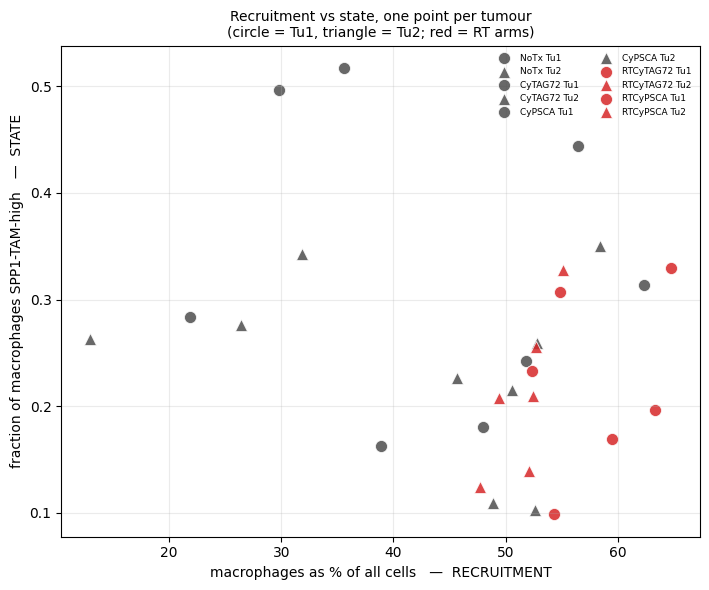

In [18]:
fig, ax = plt.subplots(figsize=(7.2, 6))
mk = {1: "o", 2: "^"}
for cnd in COND_PRESENT:
    s = prev[prev["cond"] == cnd]
    if s.empty:
        continue
    for loc, sub in s.groupby("tumor_loc", observed=True):
        ax.scatter(sub["mac_pct_of_cells"], sub["frac_tam_high"], s=75, marker=mk.get(loc, "s"),
                   color=colors.get(cnd, "k"), alpha=0.85, linewidths=0.6, edgecolors="w",
                   label=f"{cnd} Tu{loc}")
ax.set_xlabel("macrophages as % of all cells   —  RECRUITMENT")
ax.set_ylabel("fraction of macrophages SPP1-TAM-high   —  STATE")
ax.set_title("Recruitment vs state, one point per tumour\n(circle = Tu1, triangle = Tu2; red = RT arms)",
             fontsize=10)
ax.legend(fontsize=6.5, ncol=2, frameon=False); ax.grid(alpha=0.25)
fig.tight_layout(); fig.savefig(FIG_DIR / "sc_spp1tam_recruitment_vs_state.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)

## 5. Which macrophage subtype are the SPP1-TAMs, per arm?

01c §4b found an M2 skew; 05 found M1-like macrophages expand 2-3 log2 with treatment. So the
subtype identity of the SPP1-TAM pool may itself shift with therapy. Composition is computed
**within** the SPP1-TAM-high pool, and compared against each arm's overall macrophage make-up.

In [19]:
rows = []
for (cnd, sub_ct), d in obs[obs["is_mac"]].groupby(["cond", "mac_subtype"], observed=True):
    tot_mac = int((obs["is_mac"] & obs["cond"].eq(cnd)).sum())
    tot_high = int((obs["tam_high"] & obs["cond"].eq(cnd)).sum())
    rows.append({"cond": cnd, "subtype": sub_ct,
                 "pct_of_macs": 100 * len(d) / tot_mac if tot_mac else np.nan,
                 "pct_of_tam_high": 100 * int(d["tam_high"].sum()) / tot_high if tot_high else np.nan,
                 "frac_high_within_subtype": float(d["tam_high"].mean())})
subtype = pd.DataFrame(rows)
subtype["log2_enrich_in_tam"] = np.log2(subtype["pct_of_tam_high"] / subtype["pct_of_macs"]).replace(
    [np.inf, -np.inf], np.nan)
subtype.to_csv(OUT_DIR / "sc_spp1tam_subtype_composition.csv", index=False)

piv = subtype.pivot_table(index="subtype", columns="cond", values="pct_of_tam_high", observed=True)
piv = piv.reindex(columns=[c for c in COND_PRESENT if c in piv.columns])
print("=== composition of the SPP1-TAM-high pool (% from each subtype), per arm ===")
print(piv.round(1).to_string())
piv2 = subtype.pivot_table(index="subtype", columns="cond", values="frac_high_within_subtype", observed=True)
piv2 = piv2.reindex(columns=[c for c in COND_PRESENT if c in piv2.columns])
print("\n=== fraction of each subtype that is SPP1-TAM-high, per arm ===")
print(piv2.round(3).to_string())
print("\n  row differences here = which macrophage subtype actually carries the program in each arm.")

=== composition of the SPP1-TAM-high pool (% from each subtype), per arm ===
cond               NoTx  CyTAG72  CyPSCA  RTCyTAG72  RTCyPSCA
subtype                                                      
Intermediate_Mac    0.0      0.0     0.0        0.0       0.1
M1_like_Mac         0.0      0.2     0.0        0.1       0.0
M2_like_Mac       100.0     99.8   100.0       99.8      99.9

=== fraction of each subtype that is SPP1-TAM-high, per arm ===
cond               NoTx  CyTAG72  CyPSCA  RTCyTAG72  RTCyPSCA
subtype                                                      
Intermediate_Mac  0.000    0.000   0.000      0.001     0.000
M1_like_Mac       0.000    0.003   0.000      0.001     0.000
M2_like_Mac       0.494    0.558   0.499      0.524     0.444

  row differences here = which macrophage subtype actually carries the program in each arm.


## 5b. The M2 decomposition — *why* SPP1-TAM prevalence falls

§5 shows two things at once: the SPP1-TAM pool is **~100% M2-like** in every arm, and the fraction
of M2 macrophages carrying the program is nearly **constant** (0.44-0.56). Those can only be
reconciled if the falling prevalence is driven by the **M2 share of the macrophage compartment**,
not by M2 cells switching the program off.

Because M1 and Intermediate macrophages carry the program at ~0%, prevalence factorises cleanly:

`frac_tam_high  =  M2 share of macrophages  x  fraction of M2s that are SPP1-TAM-high`

so on a log2 scale the change versus untreated splits additively into a **compartment** term and a
**state** term. Both are proportions computed *within* the macrophage compartment, so unlike
`mac_pct_of_cells` neither is distorted by dissociation capture bias or by tumour depletion — this
is the trustworthy version of the recruitment-vs-state decomposition in §4.

If the compartment term dominates, therapy is acting by **repolarising or depleting M2
macrophages**, not by reprogramming the SPP1-TAM state inside them — a different mechanism, and a
different therapeutic implication.

=== M2 decomposition of SPP1-TAM prevalence ===
           n  frac_tam_high  m2_share  m2_rate
cond                                          
NoTx       6          0.363     0.766    0.469
CyTAG72    5          0.319     0.579    0.545
CyPSCA     6          0.169     0.353    0.469
RTCyTAG72  6          0.277     0.542    0.512
RTCyPSCA   6          0.156     0.360    0.432

  factorisation frac_tam_high ~ m2_share x m2_rate: max |err| = 0.0011   (small = M1/Intermediate carry ~none of the program)

=== log2 change vs NoTx: compartment term vs state term ===
           n  log2_M2_compartment  log2_within_M2_state  log2_prevalence  pct_movement_from_compartment
cond                                                                                                   
CyTAG72    5               -0.394                 0.272           -0.119                         59.195
CyPSCA     6               -1.144                 0.022           -1.122                         98.118
RTCyTAG72  6       

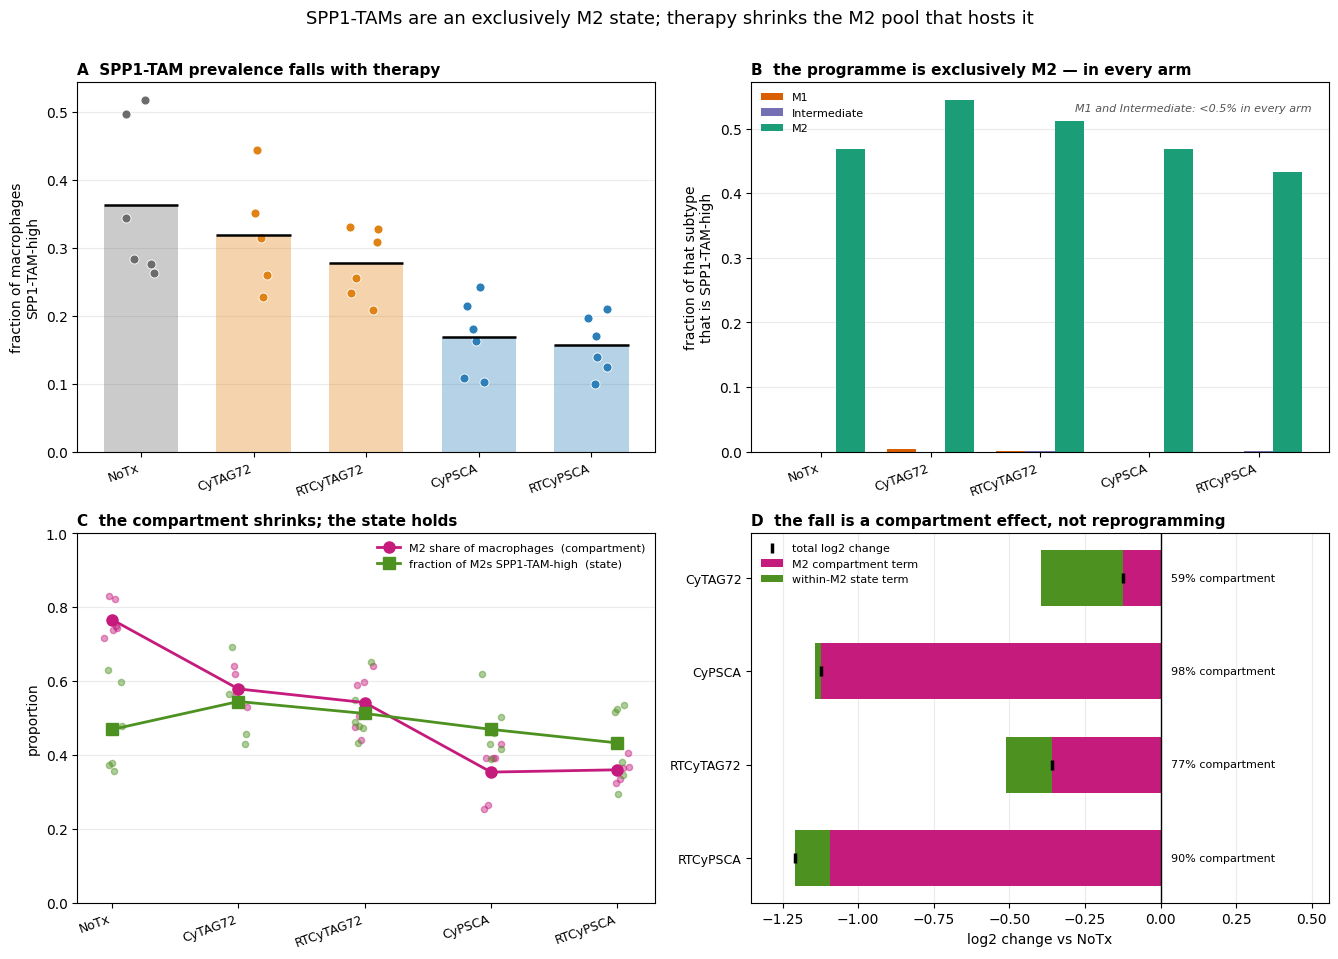


saved -> /coh_labs/yunroseli/Jona/CAR-T/results/spp1_analysis/figures/sc_spp1tam_m2_decomposition.png


In [20]:
# %% -- 5b. M2 decomposition of SPP1-TAM prevalence + summary figure --
M2, M1, INT = "M2_like_Mac", "M1_like_Mac", "Intermediate_Mac"
SUBTYPES = [s for s in [M1, INT, M2] if s in set(obs.loc[obs["is_mac"], "mac_subtype"])]

rows = []
for samp, d in obs.groupby("sample", observed=True):
    macs = d[d["is_mac"]]
    if len(macs) < MIN_MACS:
        continue
    m = d.iloc[0]
    rec = {"sample": samp, "cond": m["cond"], "tumor_loc": m["tumor_loc"], "group": m["group"],
           "n_mac": len(macs), "frac_tam_high": float(macs["tam_high"].mean())}
    for s in SUBTYPES:
        sub = macs[macs["mac_subtype"] == s]
        rec[f"share_{s}"] = len(sub) / len(macs)
        rec[f"rate_{s}"] = float(sub["tam_high"].mean()) if len(sub) else np.nan
    # the factorisation, and how much of prevalence the M2 term alone explains
    rec["m2_share"], rec["m2_rate"] = rec[f"share_{M2}"], rec[f"rate_{M2}"]
    rec["approx_from_M2"] = rec["m2_share"] * (rec["m2_rate"] if np.isfinite(rec["m2_rate"]) else 0.0)
    rows.append(rec)
m2d = pd.DataFrame(rows)
m2d["cond"] = pd.Categorical(m2d["cond"], COND_PRESENT, ordered=True)
m2d["factorisation_err"] = (m2d["approx_from_M2"] - m2d["frac_tam_high"]).abs()
m2d.to_csv(OUT_DIR / "sc_spp1tam_m2_decomposition_per_sample.csv", index=False)

by_arm = (m2d.groupby("cond", observed=True)
          .agg(n=("sample", "count"), frac_tam_high=("frac_tam_high", "mean"),
               m2_share=("m2_share", "mean"), m2_rate=("m2_rate", "mean"),
               **{f"rate_{s}": (f"rate_{s}", "mean") for s in SUBTYPES},
               **{f"share_{s}": (f"share_{s}", "mean") for s in SUBTYPES})
          .reindex(COND_PRESENT))
by_arm.to_csv(OUT_DIR / "sc_spp1tam_m2_decomposition_by_arm.csv")

print("=== M2 decomposition of SPP1-TAM prevalence ===")
print(by_arm[["n", "frac_tam_high", "m2_share", "m2_rate"]].round(3).to_string())
print(f"\n  factorisation frac_tam_high ~ m2_share x m2_rate: max |err| = "
      f"{m2d['factorisation_err'].max():.4f}   (small = M1/Intermediate carry ~none of the program)")

# log2 split vs the untreated arm: compartment term + state term
lgm = m2d[["sample", "cond", "tumor_loc"]].copy()
for k, col in {"log2_M2_compartment": "m2_share", "log2_within_M2_state": "m2_rate",
               "log2_prevalence": "frac_tam_high"}.items():
    lgm[k] = np.log2(m2d[col].where(m2d[col] > 0))
refm = lgm[lgm["cond"] == NOTX].groupby("tumor_loc", observed=True)[
    ["log2_M2_compartment", "log2_within_M2_state", "log2_prevalence"]].mean()

rows = []
for cnd, d in lgm.groupby("cond", observed=True):
    if cnd == NOTX:
        continue
    rec = {"cond": cnd, "n": len(d)}
    for k in ["log2_M2_compartment", "log2_within_M2_state", "log2_prevalence"]:
        rec[k] = float(np.mean([d[k].values[i] - refm.loc[d["tumor_loc"].values[i], k]
                                for i in range(len(d)) if np.isfinite(d[k].values[i])]))
    # share of TOTAL MOVEMENT, not of the sum: the two terms can have opposite signs (a shrinking
    # compartment with a slightly rising within-M2 rate), which makes a share-of-sum exceed 100%.
    denom = abs(rec["log2_M2_compartment"]) + abs(rec["log2_within_M2_state"])
    rec["pct_movement_from_compartment"] = (100 * abs(rec["log2_M2_compartment"]) / denom
                                            if denom else np.nan)
    rows.append(rec)
m2_split = pd.DataFrame(rows).set_index("cond").reindex([c for c in COND_PRESENT if c != NOTX])
m2_split.to_csv(OUT_DIR / "sc_spp1tam_m2_split_vs_NoTx.csv")
print(f"\n=== log2 change vs {NOTX}: compartment term vs state term ===")
print(m2_split.round(3).to_string())
print("\n  pct_movement_from_compartment >> 50 -> therapy shrinks the M2 pool that hosts the")
print("  programme, rather than switching the programme off inside M2 cells.")

# ---------------- figure ----------------
ORDER = [c for c in ["NoTx", "CyTAG72", "RTCyTAG72", "CyPSCA", "RTCyPSCA"] if c in COND_PRESENT]
CART_C = {"none": "#6c6c6c", "nonspecific": "#e08214", "PSCA": "#2c7fb8"}
ccol = {c: CART_C.get(COND_META.get(c, {}).get("cart", "none"), "#6c6c6c") for c in ORDER}
rng2 = np.random.default_rng(0)
fig, axes = plt.subplots(2, 2, figsize=(13.5, 9.5))

# A — prevalence per arm, replicate dots
ax = axes[0, 0]
for i, c in enumerate(ORDER):
    v = m2d.loc[m2d["cond"] == c, "frac_tam_high"].dropna().values
    ax.bar(i, v.mean(), color=ccol[c], alpha=0.35, width=0.66, zorder=1)
    ax.scatter(i + rng2.uniform(-0.14, 0.14, len(v)), v, s=42, color=ccol[c],
               edgecolors="w", linewidths=0.6, zorder=3)
    ax.hlines(v.mean(), i - 0.33, i + 0.33, color="k", lw=1.8, zorder=4)
ax.set_xticks(range(len(ORDER))); ax.set_xticklabels(ORDER, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("fraction of macrophages\nSPP1-TAM-high")
ax.set_title("A  SPP1-TAM prevalence falls with therapy", fontsize=11, loc="left", fontweight="bold")
ax.grid(axis="y", alpha=0.25); ax.set_axisbelow(True)

# B — lineage restriction: rate within each subtype
ax = axes[0, 1]
w = 0.8 / len(SUBTYPES)
sub_c = {M1: "#d95f02", INT: "#7570b3", M2: "#1b9e77"}
for j, s in enumerate(SUBTYPES):
    vals = [by_arm.loc[c, f"rate_{s}"] for c in ORDER]
    ax.bar(np.arange(len(ORDER)) + j * w - 0.4 + w / 2, vals, width=w,
           color=sub_c.get(s, "#999"), label=s.replace("_like_Mac", "").replace("_Mac", ""))
ax.set_xticks(range(len(ORDER))); ax.set_xticklabels(ORDER, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("fraction of that subtype\nthat is SPP1-TAM-high")
ax.set_title("B  the programme is exclusively M2 — in every arm", fontsize=11, loc="left", fontweight="bold")
ax.text(0.97, 0.93, "M1 and Intermediate: <0.5% in every arm", transform=ax.transAxes,
        ha="right", va="center", fontsize=8, style="italic", color="#555")
ax.legend(fontsize=8, frameon=False, loc="upper left")
ax.grid(axis="y", alpha=0.25); ax.set_axisbelow(True)

# C — the two factors: compartment moves, state does not
ax = axes[1, 0]
x = np.arange(len(ORDER))
ax.plot(x, [by_arm.loc[c, "m2_share"] for c in ORDER], "-o", color="#c51b7d", lw=2, ms=8,
        label="M2 share of macrophages  (compartment)")
ax.plot(x, [by_arm.loc[c, "m2_rate"] for c in ORDER], "-s", color="#4d9221", lw=2, ms=8,
        label="fraction of M2s SPP1-TAM-high  (state)")
for i, c in enumerate(ORDER):
    v = m2d.loc[m2d["cond"] == c]
    ax.scatter(np.repeat(i, len(v)) + rng2.uniform(-.09, .09, len(v)), v["m2_share"],
               s=20, color="#c51b7d", alpha=.45, zorder=1)
    ax.scatter(np.repeat(i, len(v)) + rng2.uniform(-.09, .09, len(v)), v["m2_rate"],
               s=20, color="#4d9221", alpha=.45, zorder=1)
ax.set_xticks(x); ax.set_xticklabels(ORDER, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("proportion"); ax.set_ylim(0, 1)
ax.set_title("C  the compartment shrinks; the state holds", fontsize=11, loc="left", fontweight="bold")
ax.legend(fontsize=8, frameon=False, loc="upper right"); ax.grid(axis="y", alpha=0.25); ax.set_axisbelow(True)

# D — how the log2 drop splits
ax = axes[1, 1]
arms = list(m2_split.index); y = np.arange(len(arms))
comp = m2_split["log2_M2_compartment"].values
stat = m2_split["log2_within_M2_state"].values
ax.barh(y, comp, color="#c51b7d", label="M2 compartment term", height=0.6)
ax.barh(y, stat, left=comp, color="#4d9221", label="within-M2 state term", height=0.6)
ax.scatter(comp + stat, y, color="k", zorder=5, s=60, marker="|", linewidths=2.5,
           label="total log2 change")
span = float(np.nanmax(np.abs(np.r_[comp, comp + stat]))) or 1.0
ax.set_xlim(-1.12 * span, 0.46 * span)          # right margin holds the annotations
for i, a in enumerate(arms):
    sh = m2_split.loc[a, "pct_movement_from_compartment"]
    if np.isfinite(sh):
        ax.text(0.03 * span, i, f"{sh:.0f}% compartment", va="center", ha="left", fontsize=8)
ax.axvline(0, color="k", lw=1)
ax.set_yticks(y); ax.set_yticklabels(arms, fontsize=9); ax.invert_yaxis()
ax.set_xlabel(f"log2 change vs {NOTX}")
ax.set_title("D  the fall is a compartment effect, not reprogramming", fontsize=11,
             loc="left", fontweight="bold")
ax.legend(fontsize=8, frameon=False, loc="upper left"); ax.grid(axis="x", alpha=0.25); ax.set_axisbelow(True)

fig.suptitle("SPP1-TAMs are an exclusively M2 state; therapy shrinks the M2 pool that hosts it",
             fontsize=13, y=1.005)
fig.tight_layout()
fig.savefig(FIG_DIR / "sc_spp1tam_m2_decomposition.png", dpi=200, bbox_inches="tight")
plt.show(); plt.close(fig)
print("\nsaved ->", FIG_DIR / "sc_spp1tam_m2_decomposition.png")

## 6. The abscopal axis — paired within mouse

`X_Tu1_<rep>` and `X_Tu2_<rep>` are the same animal. `n_pairs` counts only mice with **both**
tumours present. Always read each arm against **NoTx**, which is the untreated Tu1/Tu2 baseline.

=== paired within-mouse log2(Tu2 / Tu1) ===
           n_mice  frac_tam_high_n_pairs  mean_sig_n_pairs  frac_tam_high_log2  mean_sig_log2  mac_pct_of_cells_log2  tam_pct_of_cells_log2
cond                                                                                                                                       
NoTx            3                      3                 3              -0.515         -0.592                 -0.364                 -0.879
CyTAG72         3                      2                 2              -0.405         -0.654                 -0.201                 -0.605
CyPSCA          3                      3                 1              -0.523          3.757                  0.142                 -0.381
RTCyTAG72       3                      3                 3              -0.147         -0.398                 -0.125                 -0.272
RTCyPSCA        3                      3                 1               0.048         -0.437                 -0.216

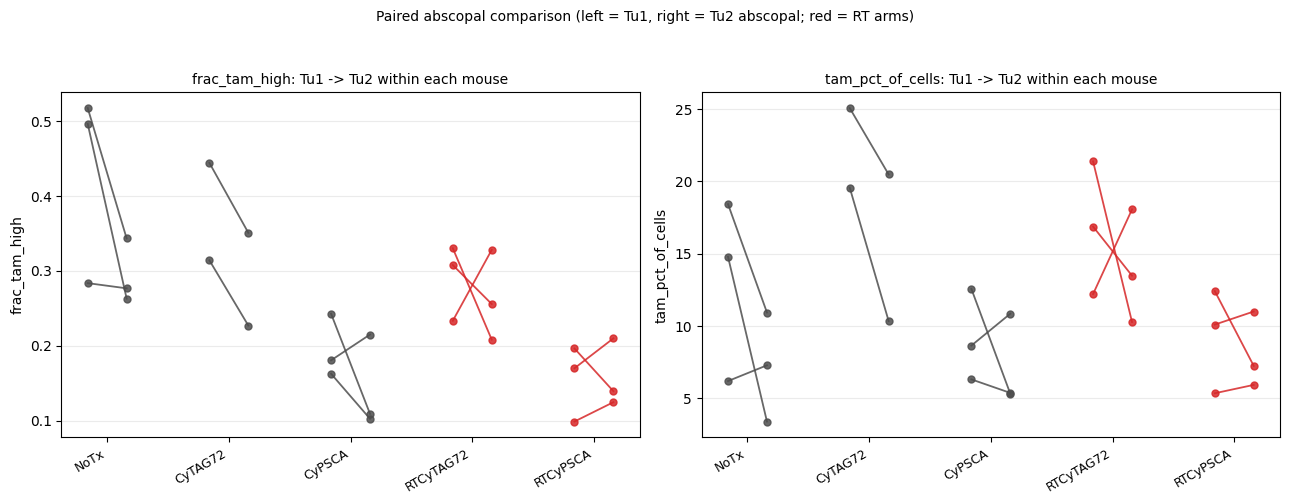

In [21]:
wide = prev.pivot_table(index=["cond", "rep", "mouse"], columns="tumor_loc",
                        values=METRICS, observed=True)
wide.columns = [f"{a}_Tu{b}" for a, b in wide.columns]
wide = wide.reset_index()
for met in METRICS:
    a, b = f"{met}_Tu1", f"{met}_Tu2"
    if a in wide.columns and b in wide.columns:
        wide[f"{met}_log2_Tu2_over_Tu1"] = np.log2(wide[b] / wide[a]).replace([np.inf, -np.inf], np.nan)
wide.to_csv(OUT_DIR / "sc_spp1tam_paired_within_mouse.csv", index=False)

paired = (wide.groupby("cond", observed=True)
          .agg(n_mice=("mouse", "count"),
               **{f"{m}_n_pairs": (f"{m}_log2_Tu2_over_Tu1", "count") for m in STATE_METRICS},
               **{f"{m}_log2": (f"{m}_log2_Tu2_over_Tu1", "mean") for m in METRICS})
          .reindex(COND_PRESENT))
paired.to_csv(OUT_DIR / "sc_spp1tam_paired_summary.csv")
print("=== paired within-mouse log2(Tu2 / Tu1) ===")
print(paired.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, met in zip(axes, ["frac_tam_high", "tam_pct_of_cells"]):
    a, b = f"{met}_Tu1", f"{met}_Tu2"
    present_c = [c for c in COND_PRESENT if c in set(wide["cond"])]
    for i, cnd in enumerate(present_c):
        s = wide[wide["cond"] == cnd]
        for _, r in s.iterrows():
            if np.isfinite(r.get(a, np.nan)) and np.isfinite(r.get(b, np.nan)):
                ax.plot([i - 0.16, i + 0.16], [r[a], r[b]], "-o",
                        color=colors.get(cnd, "k"), ms=5, lw=1.3, alpha=0.85)
    ax.set_xticks(range(len(present_c))); ax.set_xticklabels(present_c, rotation=30, ha="right", fontsize=9)
    ax.set_ylabel(met); ax.set_title(f"{met}: Tu1 -> Tu2 within each mouse", fontsize=10)
    ax.grid(axis="y", alpha=0.25)
fig.suptitle("Paired abscopal comparison (left = Tu1, right = Tu2 abscopal; red = RT arms)",
             y=1.04, fontsize=10)
fig.tight_layout(); fig.savefig(FIG_DIR / "sc_spp1tam_paired_abscopal.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)

## 7. Treatment contrasts

Built from the arm attributes so one variable moves at a time. n=2-6 per side: **effect sizes and
sign-consistency only**, no p-values.

In [22]:
def contrast(metric, a_groups, b_groups, name, kind):
    a = prev[prev["group"].isin(a_groups)][metric].dropna().values
    b = prev[prev["group"].isin(b_groups)][metric].dropna().values
    if len(a) < 2 or len(b) < 2:
        return None
    out = {"kind": kind, "contrast": name, "metric": metric, "n_a": len(a), "n_b": len(b),
           "mean_a": a.mean(), "mean_b": b.mean(), "diff": a.mean() - b.mean(),
           "log2_ratio": float(np.log2(a.mean() / b.mean())) if a.mean() > 0 and b.mean() > 0 else np.nan}
    if len(a) >= 3 and len(b) >= 3:
        u = mannwhitneyu(a, b, alternative="two-sided")
        out["cliffs_delta"] = 2 * u.statistic / (len(a) * len(b)) - 1
    return out

RT_PAIRS = [(nr, r, cart)
            for cart in sorted({m["cart"] for m in COND_META.values() if m["cart"] != "none"})
            for nr in [c for c in COND_PRESENT if COND_META.get(c, {}).get("RT") is False
                       and COND_META.get(c, {}).get("cart") == cart]
            for r in [c for c in COND_PRESENT if COND_META.get(c, {}).get("RT") is True
                      and COND_META.get(c, {}).get("cart") == cart]]
specs = []
for nr, r, cart in RT_PAIRS:
    specs.append(([f"{r}_Tu2"], [f"{nr}_Tu2"], f"ABSCOPAL  {r}_Tu2 vs {nr}_Tu2  [{cart}]", "abscopal"))
    specs.append(([f"{r}_Tu1"], [f"{nr}_Tu1"], f"DIRECT    {r}_Tu1 vs {nr}_Tu1  [{cart}]", "direct"))
for rt_flag, tag in [(True, "with RT"), (False, "no RT")]:
    psca = [c for c in COND_PRESENT if COND_META.get(c, {}).get("RT") == rt_flag
            and COND_META.get(c, {}).get("cart") == "PSCA"]
    t72 = [c for c in COND_PRESENT if COND_META.get(c, {}).get("RT") == rt_flag
           and COND_META.get(c, {}).get("cart") == "nonspecific"]
    if psca and t72:
        specs.append(([f"{psca[0]}_Tu{t}" for t in (1, 2)], [f"{t72[0]}_Tu{t}" for t in (1, 2)],
                      f"SPECIFICITY  {psca[0]} vs {t72[0]}  [{tag}]", "specificity"))
notx = [c for c in COND_PRESENT if COND_META.get(c, {}).get("cart") == "none"]
for c in [x for x in COND_PRESENT if x not in notx]:
    specs.append(([f"{c}_Tu{t}" for t in (1, 2)], [f"{notx[0]}_Tu{t}" for t in (1, 2)],
                  f"vs UNTREATED  {c} vs {notx[0]}", "vs_untreated"))

rows = [r for met in METRICS for a, b, nm, kind in specs if (r := contrast(met, a, b, nm, kind))]
contrasts = pd.DataFrame(rows)
contrasts.to_csv(OUT_DIR / "sc_spp1tam_prevalence_contrasts.csv", index=False)
for kind in ["specificity", "abscopal", "direct", "vs_untreated"]:
    sub = contrasts[(contrasts["kind"] == kind) & (contrasts["metric"].isin(STATE_METRICS))]
    if sub.empty:
        continue
    print(f"\n=== {kind.upper()} (state metrics) ===")
    print(sub[["contrast", "metric", "n_a", "n_b", "mean_a", "mean_b", "log2_ratio"]]
          .round(3).to_string(index=False))


=== SPECIFICITY (state metrics) ===
                                     contrast        metric  n_a  n_b  mean_a  mean_b  log2_ratio
SPECIFICITY  RTCyPSCA vs RTCyTAG72  [with RT] frac_tam_high    6    6   0.156   0.277      -0.825
      SPECIFICITY  CyPSCA vs CyTAG72  [no RT] frac_tam_high    6    5   0.169   0.319      -0.919
SPECIFICITY  RTCyPSCA vs RTCyTAG72  [with RT]      mean_sig    6    6  -0.011   0.112         NaN
      SPECIFICITY  CyPSCA vs CyTAG72  [no RT]      mean_sig    6    5  -0.020   0.158         NaN

=== ABSCOPAL (state metrics) ===
                                             contrast        metric  n_a  n_b  mean_a  mean_b  log2_ratio
         ABSCOPAL  RTCyPSCA_Tu2 vs CyPSCA_Tu2  [PSCA] frac_tam_high    3    3   0.158   0.142       0.152
ABSCOPAL  RTCyTAG72_Tu2 vs CyTAG72_Tu2  [nonspecific] frac_tam_high    3    3   0.264   0.279      -0.080
         ABSCOPAL  RTCyPSCA_Tu2 vs CyPSCA_Tu2  [PSCA]      mean_sig    3    3  -0.013  -0.043         NaN
ABSCOPAL  RTCyT

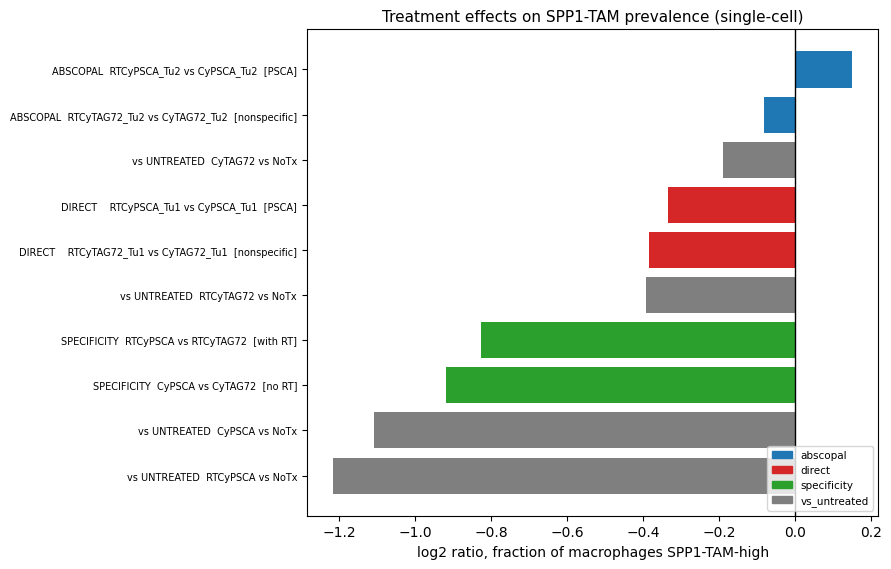

In [23]:
plot = contrasts[contrasts["metric"] == "frac_tam_high"].dropna(subset=["log2_ratio"]).sort_values("log2_ratio")
if not plot.empty:
    kind_c = {"abscopal": "#1f77b4", "direct": "#d62728", "specificity": "#2ca02c", "vs_untreated": "#7f7f7f"}
    fig, ax = plt.subplots(figsize=(9, 0.42 * len(plot) + 1.6))
    ax.barh(range(len(plot)), plot["log2_ratio"].values,
            color=[kind_c.get(k, "#999") for k in plot["kind"]])
    ax.axvline(0, color="k", lw=1)
    ax.set_yticks(range(len(plot))); ax.set_yticklabels(plot["contrast"], fontsize=7)
    ax.set_xlabel("log2 ratio, fraction of macrophages SPP1-TAM-high")
    ax.set_title("Treatment effects on SPP1-TAM prevalence (single-cell)", fontsize=11)
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color=c, label=k) for k, c in kind_c.items()], fontsize=7.5, loc="lower right")
    fig.tight_layout(); fig.savefig(FIG_DIR / "sc_spp1tam_prevalence_contrasts.png", dpi=150, bbox_inches="tight")
    plt.show(); plt.close(fig)

## 8. Sensitivity — signature vs raw Spp1

The signature is the defensible definition (multi-gene, spillover-tested, treatment-blind). Raw
`Spp1` is the naive one. If the arm ordering agrees, the prevalence result does not depend on
which definition you pick — which is the useful thing to be able to say.

In [24]:
comp = by_cond[["frac_tam_high", "frac_spp1_high_raw"]].copy()
comp.columns = ["signature_based", "raw_Spp1_based"]
comp["rank_sig"] = comp["signature_based"].rank(ascending=False)
comp["rank_raw"] = comp["raw_Spp1_based"].rank(ascending=False)
print("=== fraction of macrophages 'high', by definition, per arm ===")
print(comp.round(3).to_string())
r_s = comp[["signature_based", "raw_Spp1_based"]].corr(method="spearman").iloc[0, 1]
print(f"\nSpearman between the two definitions across arms: {r_s:+.3f}")
print("  high positive -> the prevalence ordering is definition-independent (report it).")
print("  low/negative  -> the two definitions disagree; lead with the signature and say why.")

=== fraction of macrophages 'high', by definition, per arm ===
           signature_based  raw_Spp1_based  rank_sig  rank_raw
cond                                                          
NoTx                 0.363           0.677       1.0       1.0
CyTAG72              0.319           0.328       2.0       2.0
CyPSCA               0.169           0.178       4.0       4.0
RTCyTAG72            0.277           0.305       3.0       3.0
RTCyPSCA             0.156           0.160       5.0       5.0

Spearman between the two definitions across arms: +1.000
  high positive -> the prevalence ordering is definition-independent (report it).
  low/negative  -> the two definitions disagree; lead with the signature and say why.


## 9. Summary

In [ ]:
print(f"""
==================== SUMMARY — report these back ====================
Samples / mice : {len(prev)} / {prev['mouse'].nunique()}   arms: {COND_PRESENT}
Signature      : {len(present)}/{len(sig_genes)} genes | GLOBAL SPP1-TAM-high cut = {SIG_CUT:.4f}
                 (top {int((1-TAM_HIGH_Q)*100)}% of pooled macrophages; {int(obs['tam_high'].sum()):,} cells)

Prevalence by arm:
{by_cond[['n_samples','frac_tam_high','mean_sig','mac_pct_of_cells','tam_pct_of_cells']].round(3).to_string()}

Decomposition vs NoTx (log2):
{decomp[['group','log2_recruitment','log2_state','log2_burden','driver']].round(3).to_string(index=False)}

HOW TO READ THIS
 1. frac_tam_high is THE metric: the share of macrophages carrying the SPP1-TAM program. It is a
    within-compartment proportion, so single-cell dissociation bias does NOT distort it. The
    abundance metrics (mac_pct_of_cells, tam_pct_of_cells) DO inherit that bias - quote them with
    the caveat, or quote frac_tam_high alone.
 2. §4 separates recruitment from state. 06 found spatially that treatment changes how MANY
    SPP1-TAMs there are far more than how strong each one is; check whether single-cell agrees.
 3. §7 SPECIFICITY (PSCA vs TAG72) is the CAR-T-attributable contrast. 05 found ~40% lower Spp1
    and 06 found ~2.9x lower TAM density; a third agreeing readout here would be strong.
 4. §8 says whether any of this depends on using the signature rather than raw Spp1.

WHY THIS NOTEBOOK EXISTS: 01c splits Spp1 WITHIN each sample, which fixes the treatment confound
but forces ~25% of macrophages to be 'high' in every arm. Prevalence needs the GLOBAL cut used
here. The signature is usable for this precisely because it was derived treatment-blind.

CAVEAT: n=2-3 samples per arm; effect sizes and sign-consistency only, no p-values.
=====================================================================
""")